## Making trees work - Exercise
```In this exercise you will experience with Decision Trees and Random Forests. During this part you will explore the different features of them and will plot your results. Hence, whenever exploration tasks are marked with (*), know that you are asked to plot two graphs (on the same plot): the training score against the explored feature and the test score against it.```

```~Ittai Haran```

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

```Read the dataset. In this dataset, you are provided over a hundred variables describing attributes of life insurance applicants. The task is to predict the "Response" variable.```

```the dataset can be found in: ```https://drive.google.com/open?id=1t_P64gM1M1_c2n4PvH7AZoELH2CNh6ui

In [4]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('insurance_fixed.csv')
X = df.drop(['Response'], axis = 1)
Y = df['Response']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size = 0.7, test_size = 0.3)
X_train = X_train.to_numpy()
Y_train = Y_train.to_numpy()
X_test = X_test.to_numpy()
Y_test = Y_test.to_numpy()

```We will start by using Decision trees. Use a simple DecisionTreeClassifier with default values to predict on your train and on your test. Evaluate the model using the accuracy metric, which you can find in sklearn.```

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
clf = DecisionTreeClassifier()
clf.fit(X_train, Y_train)
accuracy_score(Y_train, clf.predict(X_train))


0.9999759418755714

In [6]:
accuracy_score(Y_test, clf.predict(X_test))


0.4289082234072411

```Unfortunately, you are at overfit. Now let's try to get better. Try playing with the max depth of the tree, for``` $1\leq depth \leq25$ ```(*) (This means you are asked to plot some graphs, remember? :) )```

```Choose the optimal max_depth based on the graph you got.```

Best depth: 8


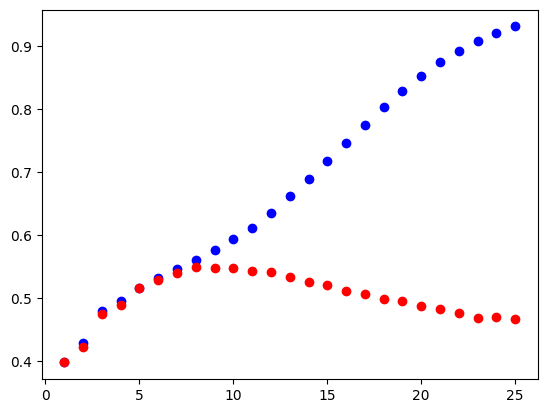

In [8]:
acc_in = [] 
acc_out = [] 
for d in range(1, 26):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, Y_train)
    acc_in.append(accuracy_score(Y_train, clf.predict(X_train)))
    acc_out.append(accuracy_score(Y_test, clf.predict(X_test)))
plt.scatter(range(1,26), acc_in, color='blue')
plt.scatter(range(1,26), acc_out, color='red')
max_depth = np.argmax(acc_out) + 1
print(f"Best depth: {max_depth}")

```Choose the best max_depth you found. Now try playing with min_samples_leaf. use the following values:
[1, 10, 100, 300,700, 1000]. Do it also with max_depth = 20. What can we learn from the graphs? Please answer the question ```$\ \underline{in\ another\ cell}$```.(*)```

Answer: very small min_samples_leaf values could lead to overfitting while very large ones could lead to underfitting

[[0.549031714847039, 0.5488071849564974, 0.5361773786135279, 0.5170362054448499, 0.49666011787819253, 0.4913836654504631], [0.4873982598933483, 0.4993544765646927, 0.5398259893348302, 0.5170362054448499, 0.49666011787819253, 0.4913836654504631]]


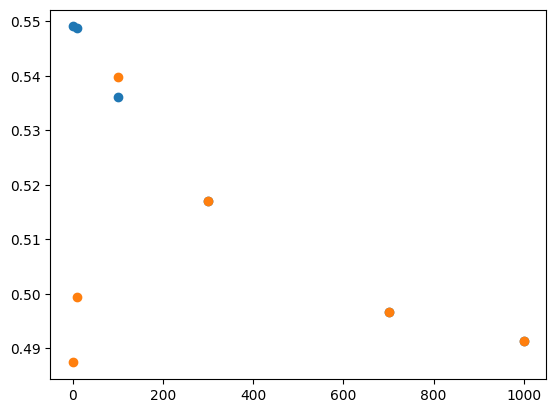

In [9]:
accs = [] 
possible_ms = [1, 10, 100, 300, 700, 1000]
for d in [max_depth, 20]:
    acc = [] 
    for ms in possible_ms:
        clf = DecisionTreeClassifier(max_depth=d, min_samples_leaf=ms)
        clf.fit(X_train, Y_train)
        acc.append(accuracy_score(Y_test, clf.predict(X_test)))
    accs.append(acc)
print(accs)
for acc in accs:
    plt.scatter(possible_ms, acc)



```Decision Tree is a very nice algorithm, especially because it is very intuitive and explainable. We can even draw it!
Train a simple Decision Tree with max_depth = 3. Call it basic_tree and run the cell below. Examine the file tree.png you created.```

In [135]:
basic_tree = DecisionTreeClassifier(max_depth=3)
basic_tree.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [136]:
from sklearn.tree import export_graphviz
export_graphviz(basic_tree, out_file = 'tree.dot', filled  = True,
                rounded = True, feature_names = df.drop(columns=['Response']).columns)
!dot -Tpng tree.dot -o tree.png

C:\Users\yovel\AppData\Roaming\Python\Python314\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\yovel\AppData\Roaming\Python\Python314\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  res = process_handler(cmd, _system_body)
C:\Users\yovel\AppData\Roaming\Python\Python314\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


```Look at the tree you got. What, would you say, are the most important features?
As you recall, we talked about feature importance in the lecture notes. Use the attribute feature_importance_ of your tree to get a list of the most important features.```

In [137]:
basic_tree.feature_importances_

array([0.        , 0.        , 0.05000642, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.56122627,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.1907489 ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.1980184 , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

```We will now move to Random Forest. Repeat the exlporations tasks with a Random forest with 100 trees (max depth and min samples leaf). In addition, vary the number of trees between 10 and 400, while maintaining low max_depth (*) and the max_feature parameter, between 0.1 and 1 (*). Try explaining the graphs you see ```$\ \underline{in\ a\ different\ cell}$```. Use the flag n_jobs = -1 in your experiments to accelerate your computation time. Make sure to understand where your model is overfitted.```

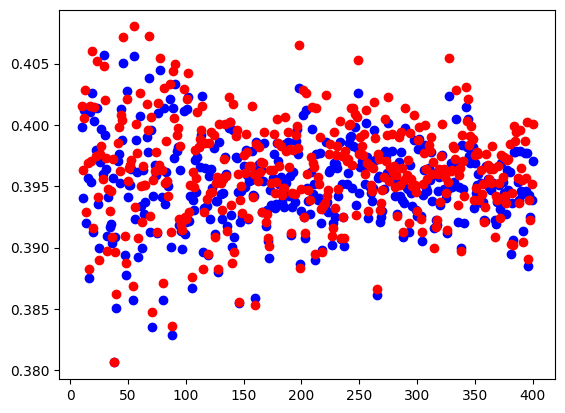

In [10]:
from sklearn.ensemble import RandomForestClassifier
acc_in = []
acc_out = [] 
dep = 3
for no_trees in range(10, 401):
    clf = RandomForestClassifier(max_depth=dep, n_estimators=no_trees, n_jobs=-1)
    clf.fit(X_train, Y_train)
    acc_in.append(accuracy_score(Y_train, clf.predict(X_train)))
    acc_out.append(accuracy_score(Y_test, clf.predict(X_test)))
plt.scatter(range(10,401), acc_in, color='blue')
plt.scatter(range(10,401), acc_out, color='red')

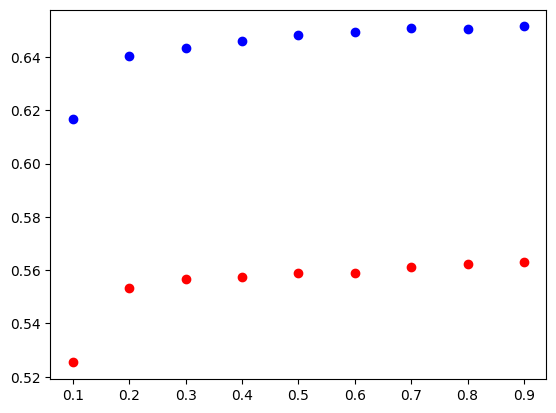

In [167]:
acc_in = []
acc_out = [] 
dep = 11
rang = np.arange(0.1, 1, 0.1)
for mf in rang:
    clf = RandomForestClassifier(max_depth=dep, max_features=mf, n_jobs=-1)
    clf.fit(X_train, Y_train)
    acc_in.append(accuracy_score(Y_train, clf.predict(X_train)))
    acc_out.append(accuracy_score(Y_test, clf.predict(X_test)))
plt.scatter(rang, acc_in, color='blue')
plt.scatter(rang, acc_out, color='red')

Best depth: 22


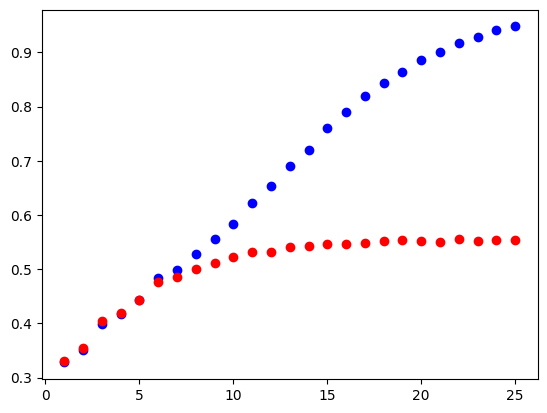

In [139]:
acc_in = [] 
acc_out = [] 
for d in range(1, 26):
    clf = RandomForestClassifier(max_depth=d, n_jobs=-1)
    clf.fit(X_train, Y_train)
    acc_in.append(accuracy_score(Y_train, clf.predict(X_train)))
    acc_out.append(accuracy_score(Y_test, clf.predict(X_test)))
plt.scatter(range(1,26), acc_in, color='blue')
plt.scatter(range(1,26), acc_out, color='red')
print(f"Best depth: {np.argmax(acc_out) + 1}")

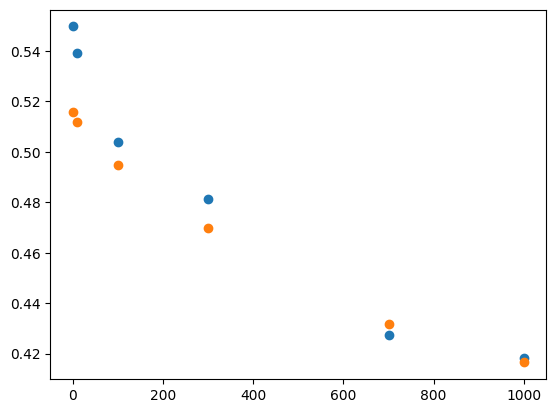

In [ ]:
max_depth = np.argmax(acc_out) + 1
accs = [] 
possible_ms = [1, 10, 100, 300, 700, 1000]
for d in [max_depth, 9]:
    acc = [] 
    for ms in possible_ms:
        clf = RandomForestClassifier(max_depth=d, min_samples_leaf=ms, n_jobs=-1)
        clf.fit(X_train, Y_train)
        acc.append(accuracy_score(Y_test, clf.predict(X_test)))
    accs.append(acc)
for acc in accs:
    plt.scatter(possible_ms, acc)



Number of trees: Data is all over the place but we see that train accuracy is usually very close to test accuracy

Max features: Growth slows down significantly, no overfitting in the data we checked (test accuracy keeps going up) but maybe in slightly larger values

Max depth: Test accuracy's growth is slowed down very quickly, actual overfitting only starts happening in the final values

Min samples leaf: Very small values cause overfitting and very large ones cause underfitting

```As you could see, at least one of your graphs turned out to be very noisy. Use K Fold cross validation to evalute your model more accurately. In K Fold cross validation we split our data into K segments, and for each ```$\ 1\leq i\leq K\ $``` we test our model on the i-th segment while training it using the others.```

c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

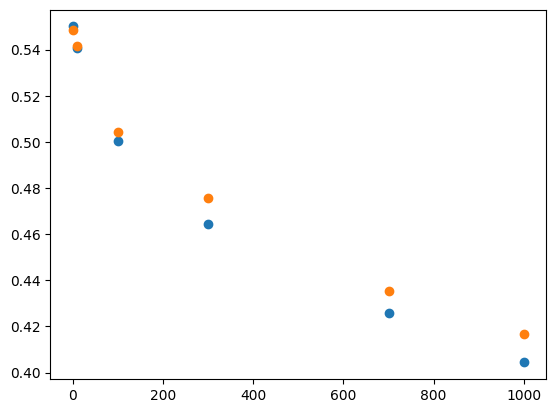

In [ ]:
from sklearn.model_selection import KFold
K = 10
kf = KFold(K)

accs_in = []
accs_out = [] 
possible_ms = [1, 10, 100, 300, 700, 1000]
for d in [max_depth, 9]:
    acc_in = []
    acc_out = []  
    for ms in possible_ms:
        clf = RandomForestClassifier(max_depth=d, min_samples_leaf=ms, n_jobs=-1)
        cross_val_acc = 0
        for train, val in kf.split(X_train):
            clf.fit(X_train[train], Y_train[train])
            cross_val_acc += (accuracy_score(Y_train[val], clf.predict(X_train[val])))/K
        clf.fit(X_train, Y_train)
        acc_in.append(cross_val_acc)
        acc_out.append(accuracy_score(Y_test, clf.predict(X_test)))
    accs_in.append(acc_in)
    accs_out.append(acc_out)
plt.scatter(possible_ms, accs_in[0])
plt.scatter(possible_ms, accs_out[0])


    

```Use the Random Forest to surpass the best score you got using Decision Tree.```

In [ ]:
ms = 1

## Extra thinking on feature importance

```We talked about feature importance in the lecture notes. get the feature importance of each feature using a decision tree and using a random forest. Use in both cases the best hyper parameters you found so far. Discuss the differences between the answers``` $\underline{in\ a\ cell}$.

In [14]:
opt_tree = DecisionTreeClassifier(max_depth=9, min_samples_leaf=100)
opt_forest = RandomForestClassifier(max_depth=max_depth)
opt_tree.fit(X_train, Y_train)
opt_forest.fit(X_train, Y_train)
print(f"forest importances: {opt_forest.feature_importances_}")
print(f"tree importances: {opt_tree.feature_importances_}")

forest importances: [3.12866848e-04 3.28006623e-03 7.25963815e-02 1.29849176e-04
 5.23443590e-04 2.35277639e-04 2.58398756e-02 1.92435020e-02
 1.38027950e-01 2.02141197e-01 7.95207937e-03 5.30811807e-03
 3.10278973e-03 2.11378357e-03 1.25694804e-03 5.72461575e-03
 2.41848098e-03 1.73017394e-03 2.28687866e-03 6.60440253e-04
 1.77357220e-03 2.96520984e-02 2.90111128e-03 8.29640834e-04
 2.88407248e-03 1.08155585e-03 1.45198828e-03 5.31041537e-03
 1.03723620e-03 1.27640904e-03 1.06073104e-03 3.22299587e-03
 1.41388956e-02 1.13498618e-02 1.52400081e-02 1.30192483e-02
 5.76977732e-03 3.53262239e-03 1.02839881e-03 8.08545986e-02
 5.31367873e-04 5.12787946e-03 4.62512529e-04 8.47857147e-04
 7.71231040e-04 4.55457608e-04 2.04434053e-04 6.26985564e-04
 5.19844877e-03 4.31830881e-04 2.73505154e-02 3.63533270e-03
 6.94284853e-04 1.13543650e-03 5.14390455e-04 9.79945373e-04
 5.45315976e-04 3.26561515e-04 8.58323717e-02 2.14144994e-03
 5.58135040e-04 6.26921788e-04 1.26590309e-03 3.27456560e-03
 1.0

Forest importances are spread relatively evenly, whereas tree importances are mostly $0\text{s}$ with non zero values being bigger, since in trees most features aren't picked

```We can define a concept of feature importance for linear regression: Suppose you have two features, ```$x_1$ ```and``` $x_2$. ```Suppose that you got a linear regression of the form```

$y = 100\cdot x_1 + 1\cdot x_2$

```What feature is more important? What if we have -100 instead of 100? Generalize this idea to any number of features. Train a linear regression on your data and get the feature importances.```

In [144]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X_train, Y_train)
print(np.abs(lin.coef_))

[1.16687782e-01 8.19512736e-03 8.03025277e-01 1.69640150e-01
 2.70110759e-02 3.88850076e-02 1.42649783e+00 3.28490273e+00
 5.78441998e+00 1.98089293e+00 1.37875095e-01 2.49063566e-03
 1.72521807e-01 4.56814924e-01 4.25004327e-02 5.36404166e-02
 1.44835541e-01 8.91030326e-01 6.44880908e-03 3.08554441e-02
 6.38112279e-01 1.87393909e-01 3.49409251e-01 3.73307085e-01
 4.06679849e-01 1.15792031e-01 5.16793103e-02 3.03116073e+00
 7.45523208e-02 1.21550739e-01 3.63790271e-02 1.51725185e-02
 4.68800769e-01 2.51048371e-01 5.65771902e-01 3.95075236e-01
 5.77398289e-03 1.11808159e-04 2.25826989e-01 1.22284210e+00
 1.78207852e+00 1.51099987e-01 5.29465065e-01 5.58596815e-02
 1.09132829e-02 1.63348593e-03 4.99732518e-01 2.22444233e-01
 3.03171570e-01 2.36908540e-01 5.49327870e-03 3.03640657e-02
 5.84482766e-01 8.26888517e-01 5.29312395e-01 9.69609311e-01
 1.04293675e-01 3.17398187e-01 4.18105465e-01 2.16287785e-03
 3.24057325e-01 5.23944438e-01 5.12567216e-01 3.01023246e-01
 6.60262614e-02 9.583204

## Feature selection
```We will now try using the feature_importance we can get from our models to do a wise feature selection.```

Do the following:



*   ```Take the best Random Forest model you got at the last part.```
*   ```Select the top 20 feature with the greatest feature importance.```
*   ```Train a KNN model with n_neighbors = 8 (and n_jobs = -1). What is its accuracy?```
*   ```Train a KNN model using the 20 features you found, again with n_neighbors = 8 (and n_jobs = -1). What is its accuracy? What can we learn from it?```
*   ```Repeat the two last tasks, this time with the best Random Forest configuration you found. Can you explain the results?```
*   ```Draw a graph where the y axis is a feature_importance sum, and the x axis is the number of features you must take to get this sum. How can this graph help you to explain your results?```

In [145]:
from sklearn.neighbors import KNeighborsClassifier

most_important = opt_forest.feature_importances_.argsort()[-20:]
knn = KNeighborsClassifier(20, n_jobs=-1)
knn.fit(X_train, Y_train)
print(f"KNN on all features: {accuracy_score(Y_test, knn.predict(X_test))}")
X_train_important = X_train[:, most_important]
X_test_important = X_test[:, most_important]
knn.fit(X_train_important, Y_train)
print(f"KNN on most important features: {accuracy_score(Y_test, knn.predict(X_test_important))}")
opt_forest.fit(X_train, Y_train)
print(f"Optimal forest on all features: {accuracy_score(Y_test, opt_forest.predict(X_test))}")
opt_forest.fit(X_train_important, Y_train)
print(f"Optimal forest on most important features: {accuracy_score(Y_test, opt_forest.predict(X_test_important))}")





c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

KNN on all features: 0.35773224810552906
KNN on most important features: 0.3690148751052484


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

Optimal forest on all features: 0.5548133595284872


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

Optimal forest on most important features: 0.5325849003648611


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

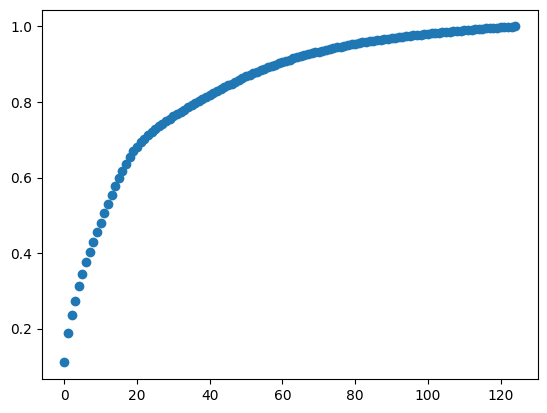

In [146]:
opt_forest.fit(X_train, Y_train)
sorted_features = opt_forest.feature_importances_
sorted_features.sort()
plt.scatter(np.arange(len(sorted_features)), np.cumsum(sorted_features[::-1]))

Answers: 

Accuracies are very similar whether we use all features or the top 20 most important ones, so importance actually measures importance. 

In addition we don't need many features to get almost all of the importance, meaning a lot of our features are either only very slightly relevant or actually noise.

```We will now implement a primitive reduction of Seffi's feature selection method (you are encouraged to ask him about it):```
- ```Take the best Random Forest model you found.```
- ```Create a dictionary that holds {feature: its importance}.```
- ```Transpose the df matrix, so we may think on the columns as 'samples' and vice versa.```
- ```Normalize each 'sample', so its length is 1.```
- ```Use KMeans with n_clusters = 20 on the 'samples'.```
- ```From each cluster take the feature with the highest feature importance.```

In [147]:
from sklearn.cluster import KMeans
def get_important_features(opt_forest):
    col_samples = df.T.copy()
    important_features = []
    importances = {col_samples.index[i]: f for i, f in enumerate(opt_forest.feature_importances_)}
    for i in range(len(col_samples.iloc[0, :])):
        col_samples.iloc[:, i] = col_samples.iloc[:, i] / np.linalg.norm(col_samples.iloc[:, i].to_numpy())
    km = KMeans(n_clusters=20).fit(col_samples)
    print(col_samples.shape)
    kmeans = km.predict(col_samples)
    for i in range(20):
        features_in_cluster = col_samples[kmeans == i].index.to_series()
        importances_in_cluster = features_in_cluster.map(importances)
        cluster = pd.DataFrame({'Feature': features_in_cluster, 'Importance': importances_in_cluster})
        if cluster['Importance'].any():
            important_features.append(cluster['Importance'].idxmax(skipna=True))
    return important_features
get_important_features(opt_forest)


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

(126, 59381)


['BMI',
 'Medical_History_2',
 'Medical_History_15',
 'Product_Info_3',
 'Family_Hist_1',
 'Medical_History_24',
 'Medical_History_1',
 'InsuredInfo_3',
 'Employment_Info_2',
 'Medical_History_4',
 'Medical_History_10',
 'Ht',
 'Medical_History_29',
 'Medical_History_32',
 'Employment_Info_3',
 'Medical_History_23',
 'Insurance_History_4',
 'Insurance_History_3',
 'Medical_History_41']

## Ensemble methods and stacking
```In this part we will explore the concept of model stacking: that is, training a model, the combining model, on the outputs of several other models. Hence, the stacking method has two steps: first we train our models, and than we train the combining model using the outputs of those models.```

```In the setting of stacking models it is very important to train the several models on one segment of the data and train the combining model on another segment. Hence, start by splitting the data to 3 segments: train_1 segment, 35% of the data, train_2 segment, 35% of the data, and test segment, the last 30% of the data.```

In [148]:
t1 = 0.35
t2 = 0.35
t_test = 0.3
df_train_1, df_train_test = train_test_split(df, test_size=t2+t_test)
df_train_2, df_test = train_test_split(df_train_test, test_size=t_test/(t2+t_test))
print(df_test.shape, df_train_1.shape, df_train_2.shape)

(17815, 126) (20783, 126) (20783, 126)


```Our first experiment is as follows: train a random forest of simple decision trees (30 trees, max_depth = 3), using train_1. Use the estimators of the forest to create 30*8=240 features: for each estimator get the probabilities it gives for the target to belong to any of the classes. You can get the list of the estimators using RandomForestClassifier.estimators_ and have the probabilities mentioned using model.predict_proba.
Using the new features you got (and them only), train a logistic regression (LogisticRegression).
Compare between the accuracy of the first random forest (on the test segment) and the accuracy of the stacked models (again, on the test segment).```

In [149]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
df = pd.read_csv('insurance_fixed.csv')
X = df.drop(['Response'], axis = 1)
Y = df['Response']
X_train_forest = df_train_1.drop(['Response'], axis=1)
Y_train_forest = df_train_1['Response'].to_numpy()
X_train_log = df_train_2.drop(['Response'], axis=1)
Y_train_log = df_train_2['Response'].to_numpy()

X_test = df_test.drop(['Response'], axis=1)
Y_test = df_test['Response'].to_numpy()
opt_forest = RandomForestClassifier(max_depth=20)
opt_forest.fit(X_train_forest, Y_train_forest)
print(f"Forest accuracy: {accuracy_score(Y_test, opt_forest.predict(X_test))}")
log_reg = LogisticRegression()
important_features = get_important_features(opt_forest)
log_reg.fit(X_train_log[important_features], Y_train_log)
print(f"Logistic regression accuracy: {accuracy_score(Y_test, log_reg.predict(X_test[important_features]))}")

c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

Forest accuracy: 0.5348301992702779
(126, 59381)
Logistic regression accuracy: 0.3438675273645804


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


```We will conduct a similar experiment: create a set of at least 5 different models, of different kinds - use algorithms we talked about in the course. Stack them to get a better model. Compare the accuracies of the models to the accuracy of your stacked model.```

In [150]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegressionCV, LogisticRegression, RidgeClassifier, RidgeClassifierCV
from sklearn.ensemble import StackingClassifier
tree = DecisionTreeClassifier(max_depth=9)
knn = KNeighborsClassifier(n_neighbors=10)
lin = LinearRegression()
log = LogisticRegression()
ridge = RidgeClassifier(alpha=0.01)

X_train_1 = X_train_forest
X_train_2 = X_train_log
Y_train_1 = Y_train_forest
Y_train_2 = Y_train_log
tree.fit(X_train_1, Y_train_1)
knn.fit(X_train_1, Y_train_1)
lin.fit(X_train_1, Y_train_1)
log.fit(X_train_1, Y_train_1)
clf = StackingClassifier([('tree', tree), ('knn', knn), ('lin', lin), ('log', log)], final_estimator=ridge, cv='prefit')
clf.fit(X_train_2, Y_train_2)
accuracy_score(Y_test, clf.predict(X_test))

c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5443165871456638

```As we said earlier, it is very important use two different train segments. What happens if you use the same train segment in both steps of the stacked model? Note that you now use more data to train your models, and also your combining model. Do you get better results? Do it and explain your results ```$\underline{\ in\ a\ cell\ below.}$

In [151]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegressionCV, LogisticRegression, RidgeClassifier, RidgeClassifierCV
from sklearn.ensemble import StackingClassifier
tree = DecisionTreeClassifier(max_depth=9)
knn = KNeighborsClassifier(n_neighbors=10)
lin = LinearRegression()
log = LogisticRegression()
ridge = RidgeClassifier(alpha=0.01)


tree.fit(X_train, Y_train)
knn.fit(X_train, Y_train)
lin.fit(X_train, Y_train)
log.fit(X_train, Y_train)
clf = StackingClassifier([('tree', tree), ('knn', knn), ('lin', lin), ('log', log)], final_estimator=ridge, cv='prefit')
clf.fit(X_train, Y_train)
accuracy_score(Y_test, clf.predict(X_test))

c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifie

0.5916923940499579

We use more data but it can easily lead to overfitting since the stacked model now models any biases or optimism it got from the base ones

## Extrapolation in Decision Trees

In [152]:
from sklearn.tree import DecisionTreeRegressor

X = np.linspace(0.0, 5.0, 83).reshape(-1,1)
y = np.sin(X).ravel()
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

`Try to approximate the sine function using a decision tree regressor.
Use the tree's depth to get a more accurate approximation of the sine function. Plot the results (try at least 3 differents depths).`

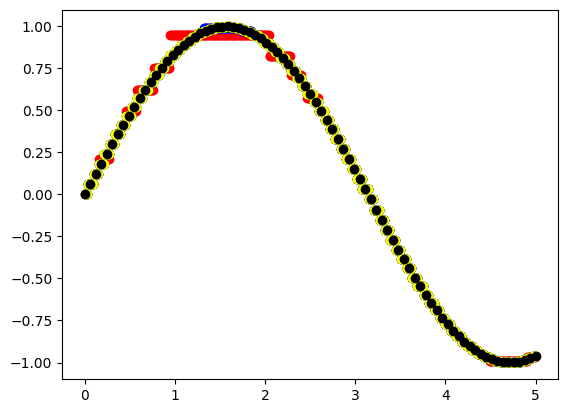

In [153]:
colors = {6: 'red', 10: 'blue', 12: 'green', 24: 'yellow'}
for d in (6, 10, 12, 24):
    color = colors[d]
    clf = DecisionTreeRegressor(max_depth=d)
    clf.fit(X, y)
    y_test = clf.predict(X_test)
    plt.scatter(X_test, y_test, color=color)
plt.scatter(X, y, color='black')

`We now define a new test set, with values out of the training set.
Try the Decision Tree regressor on this new test set.
Plot the obtained results.`

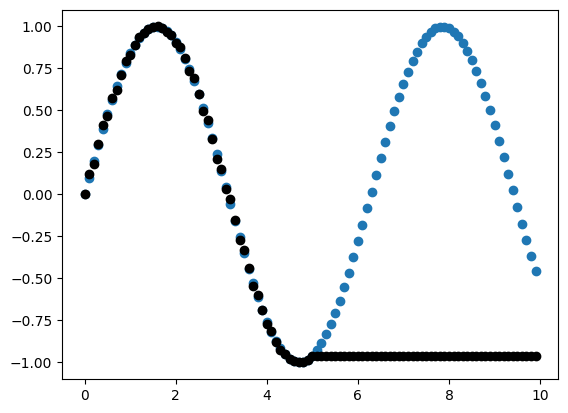

In [154]:
X_test_new = np.arange(0.0, 10.0, 0.1)[:, np.newaxis]
y_test_new = np.sin(X_test_new).ravel()
plt.scatter(X_test_new, y_test_new)
plt.scatter(X_test_new, clf.predict(X_test_new), color='black')

`Can you explain this phenomenon? How does the training of the tree causes it?`

Answer: $x\geq \alpha$ as a property

`What other model you know could overcome this situation?`

Answer: Linear regression with non linear feature transform

## Model explaining- LIMING things up
```We will try to explain complicated models using Decision Trees, and will get to know some concepts in the field.```

```We will use the MNIST data set.```

In [156]:
df = pd.read_csv('data/MNIST_train.csv')
target = df['label']
df = df.drop('label', axis = 1)
df_train, df_test, target_train, target_test = train_test_split(df, target, train_size = 0.7, test_size = 0.3, random_state=1)

```Train a LGBMClassifier on the data set, using max_depth=10, n_estimators=250 (and, of course, n_jobs = -1). How good is your model?```

In [157]:
from sklearn.ensemble import HistGradientBoostingClassifier
lgbm = HistGradientBoostingClassifier(max_depth=10, max_iter=25).fit(df_train, target_train)
accuracy_score(target_test, lgbm.predict(df_test))


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\y

0.9547619047619048

```Read The short paper Model-Agnostic Interpretability of Machine Learning by Riberio et al, which you can find in the papers directory. We are about to try to make the LIME method proposed in the paper work, using Decision Tree. We would like to train a simple and interpretable model that predicts, locally, the predictions of our LGBMClassifier.
Create the targets (train and test) for the interpretable model, as described in the paper.```

0


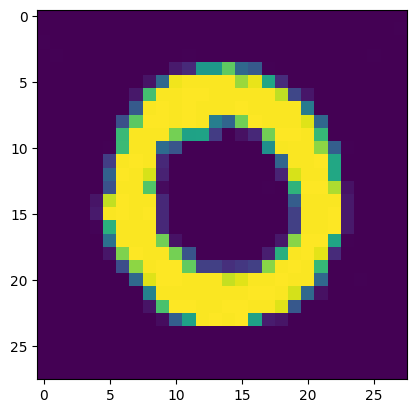

In [158]:
inst=1
rand = np.random.default_rng()
noise = rand.normal(loc=0, scale=0.2, size=df.shape)
df_lime = df + noise
target_lime = lgbm.predict(df_lime)
print(target_lime[inst])
plt.imshow(df_lime.iloc[inst].to_numpy().reshape((28,28)))

```Create a function that gets a sample and returns a weight function. The weight function will get a sample (or multiple samples) and return the each sample's weight, using the following function: ``` y_weight $ = \frac{1}{|x-y|+1}$

```where x is the original sample and y is the sample that we would like to get its weight.
Note: we are about to use this function in order to define the "neighborhood" of a point - this definition is crucial in LIME.```

In [159]:
def weight_function(sample):
    sample = sample.to_numpy()
    return lambda y: 1 / (np.linalg.norm(sample-y.to_numpy()) + 1)

```Make sure your function is good: pick a sample and print the images of the 20 most weighted samples in the data set, compared to the sample you picked.```

C:\Users\yovel\AppData\Local\Temp\ipykernel_12240\2792568573.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['f'] = f_on_df


       pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
32564       0       0       0       0       0       0       0       0       0   
25175       0       0       0       0       0       0       0       0       0   
39533       0       0       0       0       0       0       0       0       0   
26108       0       0       0       0       0       0       0       0       0   
817         0       0       0       0       0       0       0       0       0   
26586       0       0       0       0       0       0       0       0       0   
20938       0       0       0       0       0       0       0       0       0   
3713        0       0       0       0       0       0       0       0       0   
23715       0       0       0       0       0       0       0       0       0   
14202       0       0       0       0       0       0       0       0       0   
26752       0       0       0       0       0       0       0       0       0   
24451       0       0       

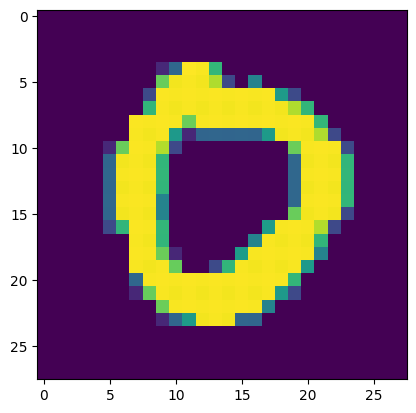

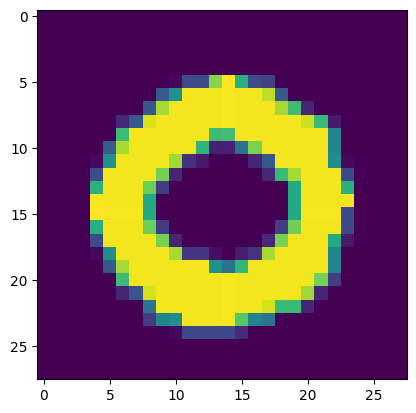

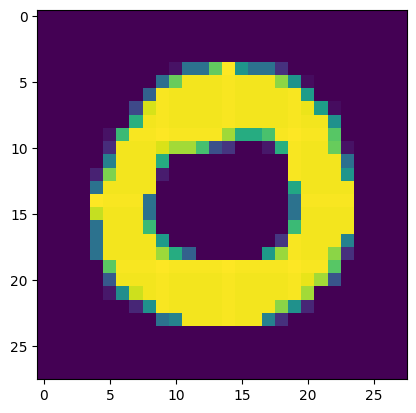

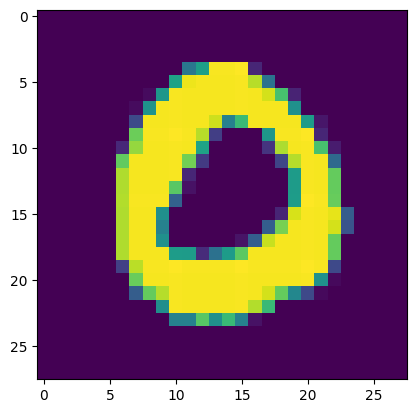

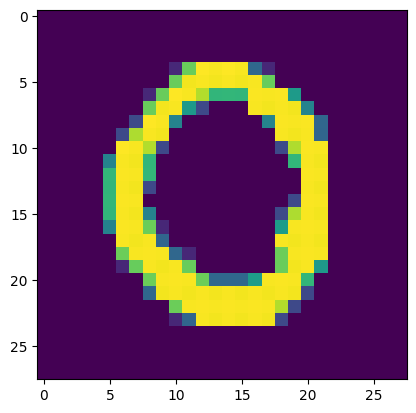

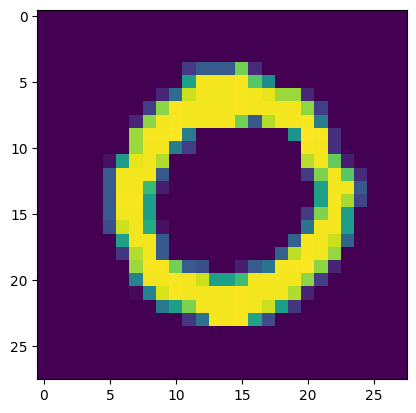

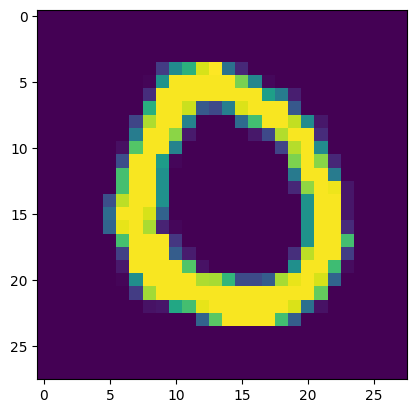

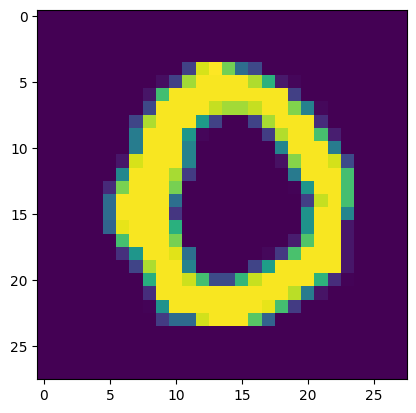

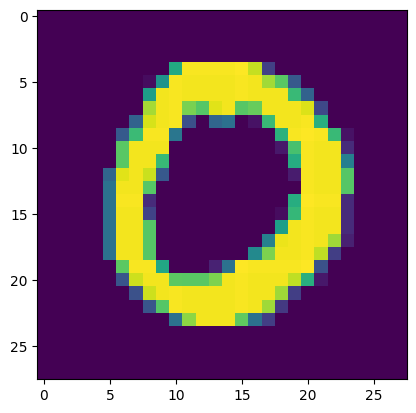

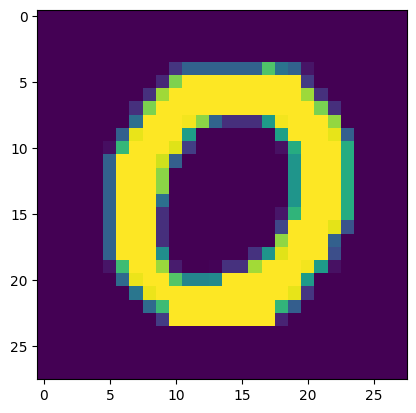

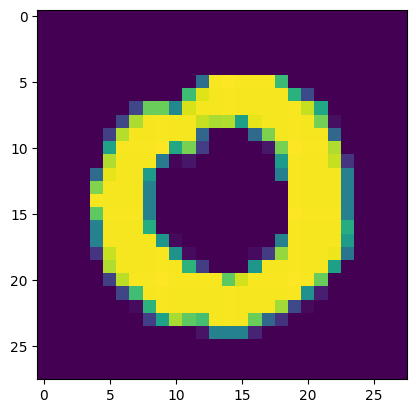

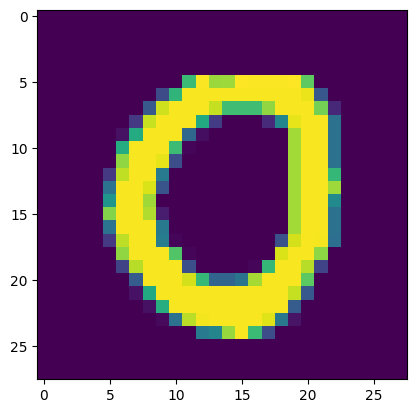

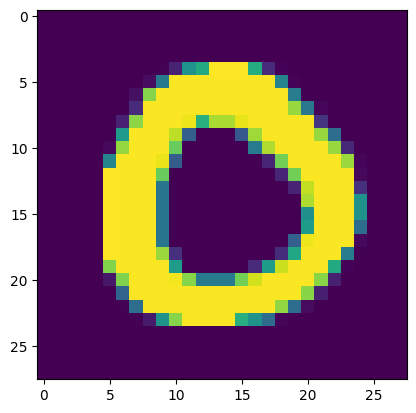

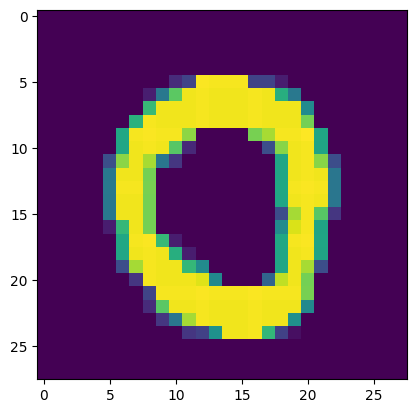

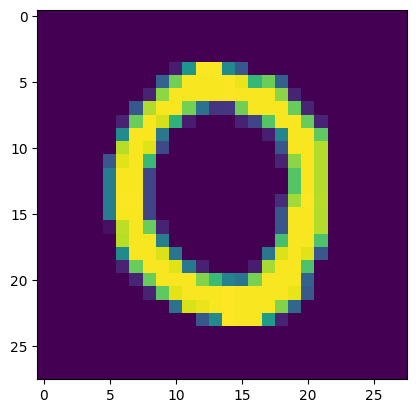

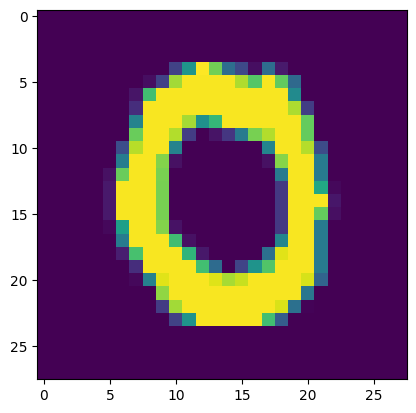

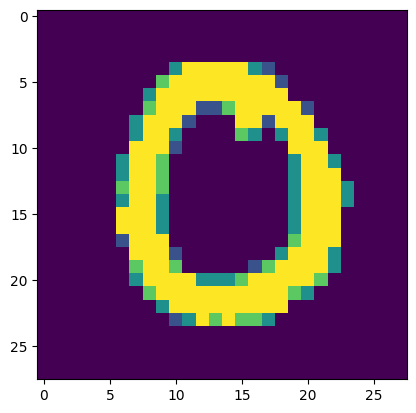

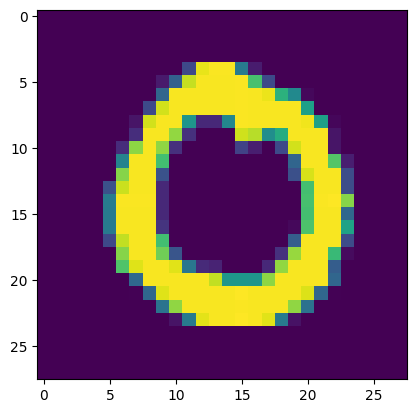

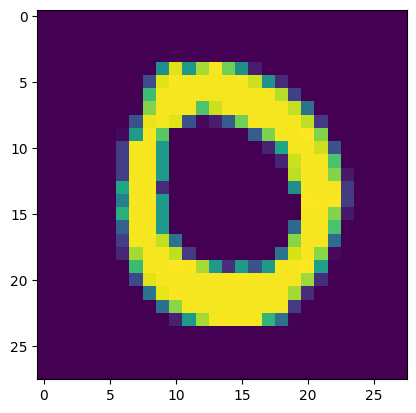

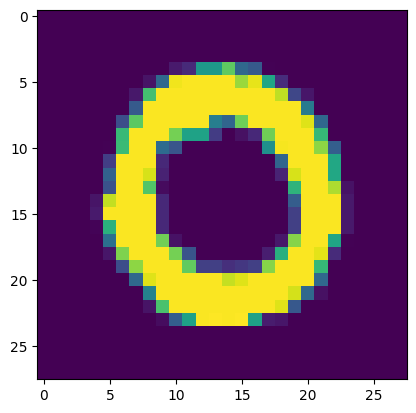

In [160]:
f = weight_function(df.iloc[1])
f_on_df = df.apply(f, axis=1)
df['f'] = f_on_df
df = df.sort_values(by='f')
df = df.drop(columns=['f'])
closest = df[-20:]
print(closest)
for img in closest.iterrows(): 
    
    plt.figure()
    plt.imshow(img[1].to_numpy().reshape((28,28)))

    

```for every digit, do the following:```
- ```take a sample of it from the dataset.```
- ```Our interpretable model is going to be a decision tree with max_depth = 5. Create the model.```
- ```Train it using the weights derived from the sample picked and the predictions of the complex LGBMClassifier model.```
- ```Create an empty image, and paint it by the feature_importance of each pixel, which you can get from the interpretable model.```
- ```Paint the image. Can you learn something from the image?```

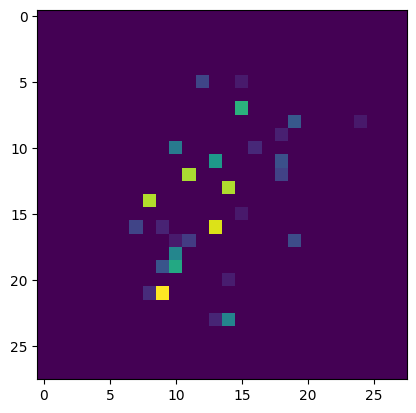

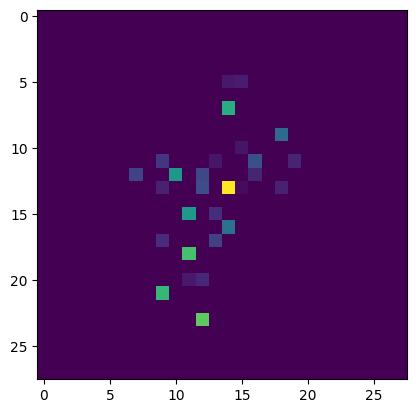

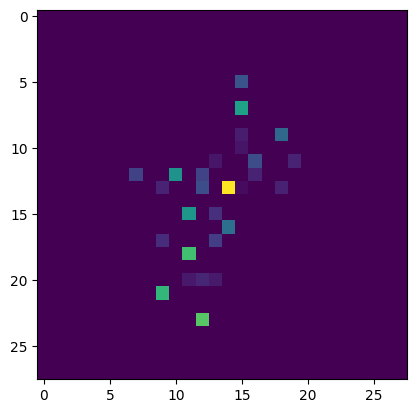

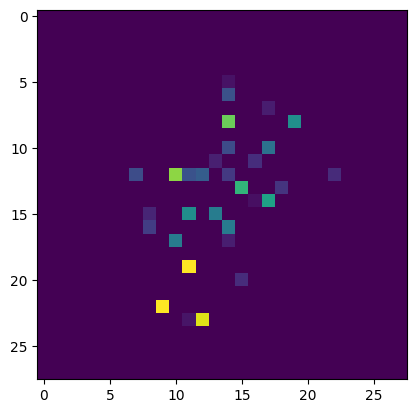

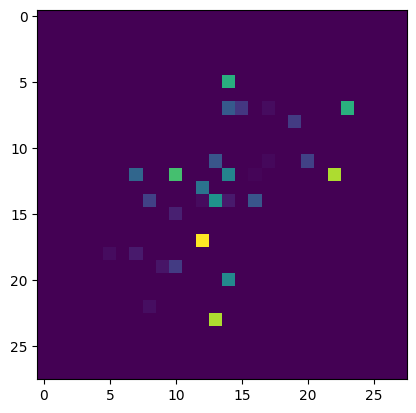

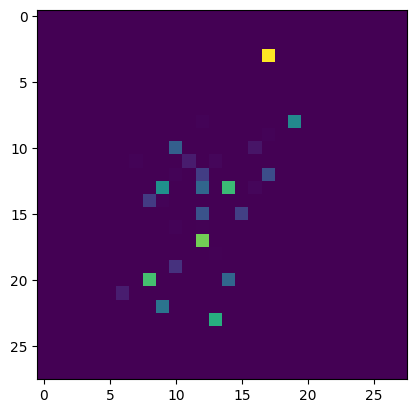

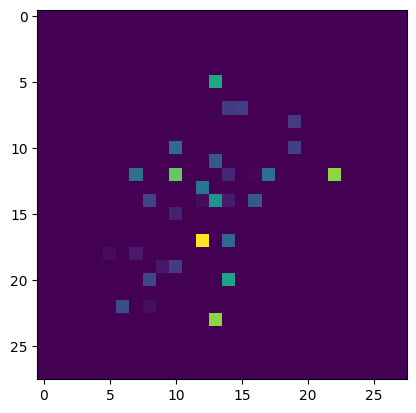

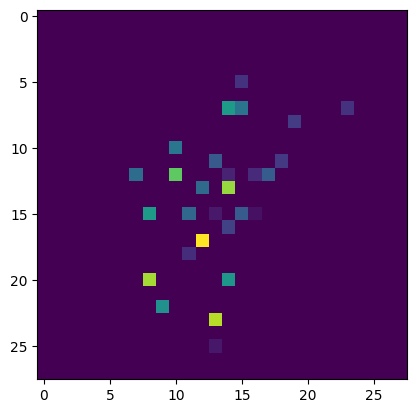

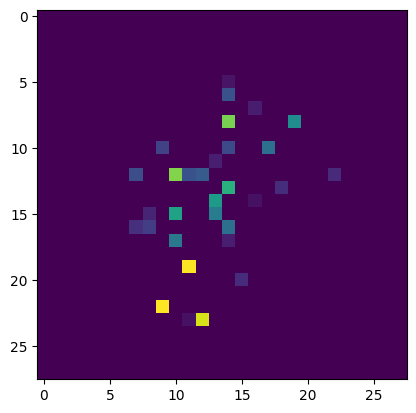

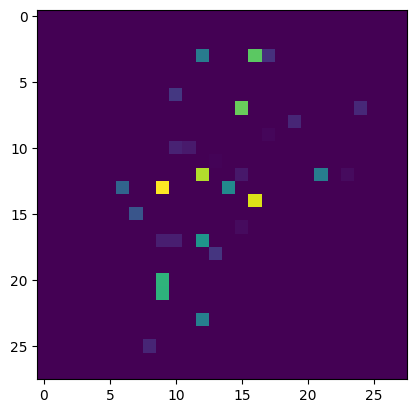

In [161]:

for digit in range(10):
    for i, t in enumerate(target):
        if digit == t:
            sample = df.iloc[i]
            break
    f = weight_function(sample)
    W = df_lime.apply(f, axis=1)
    lime = DecisionTreeClassifier(max_depth=5)
    lime.fit(df_lime, target_lime, sample_weight=W)
    plt.figure()
    plt.imshow(lime.feature_importances_.reshape((28,28)))
    
    



Answer: the center of the digit is usually most important (makes sense as a lot of the perimeter is blank)

```What are the biggest problems in LIME? What makes it limited? Regard, in your answer, the way the concept of "locality" is defined.```

Answer: Numerically close samples neednt have numerically close targets (i.e. if the model is very non linear)
so local sampling in the sense of distance doesnt necessarily make sense

```The field of interpreting models might be very important, especially when working with complex models or with unsupervised learning. This part was a small taste of it, and you are encouraged to ``` **deepen** ``` (see what I did here? :) ) your knowledge about it.```